In [4]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#df.head()
#df.tail()
#df.shape
#df.describe()
#df.info()
#df.isnull().sum()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [5]:
df_US = df[df['job_country'] == 'United States'].copy()

df_skills = df_US.explode('job_skills')

df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size().reset_index(name='skills_count')
df_skills_count = df_skills_count.sort_values(by='skills_count', ascending=False)

job_titles = df_skills_count['job_title_short'].unique()
job_titles = sorted(job_titles[:3])

df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name= 'jobs_total')

df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_percent'] = 100 * df_skills_perc['skills_count'] / df_skills_perc['jobs_total']

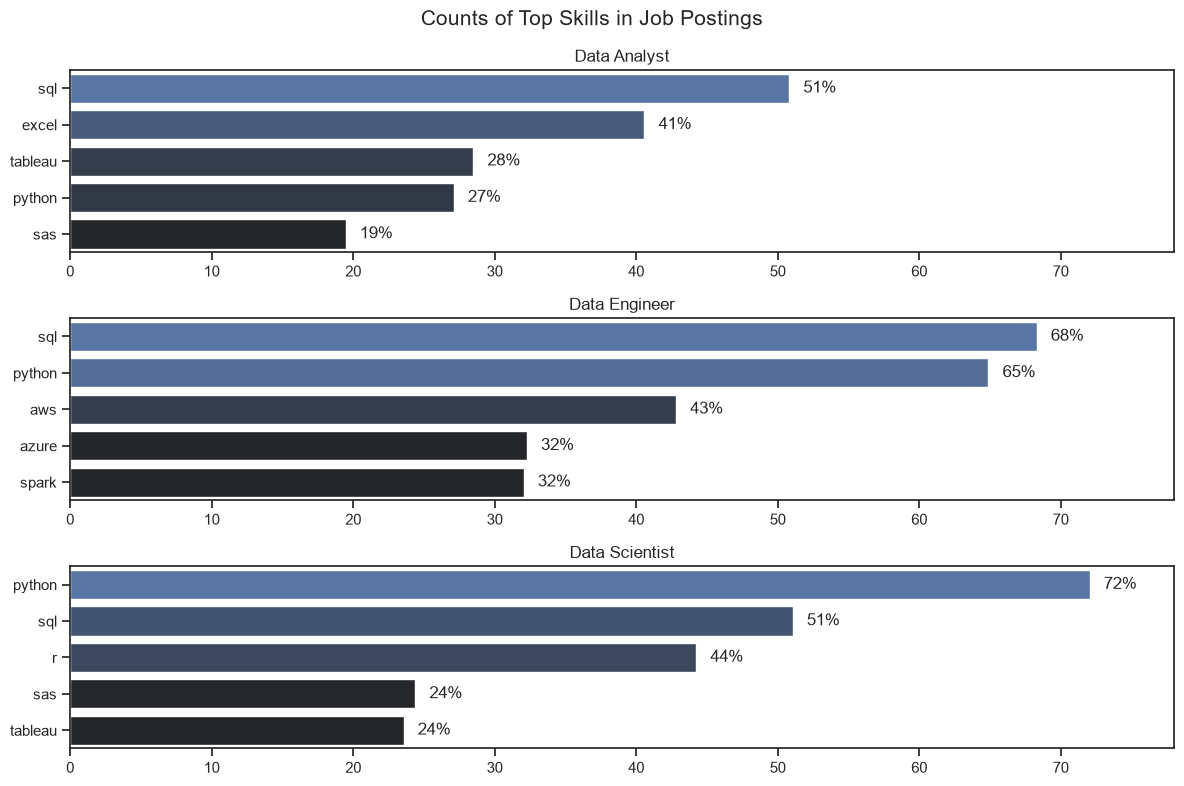

In [6]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    #df_plot.plot(kind= 'barh', x='job_skills', y= 'skill_percent', ax= ax[i], legend= False)
    sns.barplot(data= df_plot,x='skill_percent', y='job_skills',hue='skills_count', ax=ax[i], palette='dark:b')
    #ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(job_title)
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(x=v + 1, y=n, s=f'{v:.0f}%', va='center')

fig.set_size_inches(12, 8)
fig.suptitle('Counts of Top Skills in Job Postings', fontsize= 15)
fig.tight_layout()
plt.show()